# Neymanian Inference in an A/B Test: Notification Timing

## Example:
####  - Units: users
####  - Treatment Z = 1: notification at 8am
####  - Control   Z = 0: notification at 6pm
####  - Outcome: app opened within 24 hours (binary: 0/1)

## Neyman setup:
####  - Potential outcomes $Y_i$(1), $Y_i$(0) are fixed for i = 1,...,N
####  - Randomness comes ONLY from Z (treatment assignment)
####  - Estimand: finite-population ATE =  $\frac{1}{N}$$\sum_{i=1}^{N}$($Y_i$(1) - $Y_i$(0))
####  - Estimator: difference in means between treated and control

In [475]:
# first, we set a random seed for reproducibility:
import numpy as np
np.random.seed(123)

## Section 1: Construct a finite population of users and potential outcomes

In [478]:
N = 10000              # number of users in the experiment
p0 = 0.20               # baseline open rate under control (6pm)
tau_true = 0.05         # true average treatment effect (ATE): an additional 5 percentage points at 8am

#### Heterogeneous treatment effects: some users respond more, some less
#### Draw individual treatment effects around $\tau_{true}$

In [481]:
tau_i = np.random.normal(loc=tau_true, scale=0.03, size=N)

#### Potential outcomes:
#### $Y_i$(0): Bernoulli with probability $p_0$
#### $Y_i$(1): Bernoulli with probability $p_0$ + $\tau_i$, truncated to [0,1]

In [484]:
p1_i = np.clip(p0 + tau_i, 0, 1)
Y0 = np.random.binomial(n=1, p=p0, size=N)
Y1 = np.random.binomial(n=1, p=p1_i, size=N)

#### Finite-population estimand (PATE)

In [487]:
tau_fp = np.mean(Y1 - Y0)
tau_fp

0.0461

#### This is the "truth" in Neyman's sense: fixed, unknown in practice.

## Section 2: One randomized experiment: completely randomized design

In [491]:
n1 = N//2                 # treated
n0 = N - n1              # control

#### Random assignment: choose $n_1$ treated users uniformly at random

In [494]:
Z = np.zeros(N, dtype=int)
Z[np.random.choice(N, n1, replace=False)] = 1

#### Observed outcomes

In [497]:
Y_obs = (Z * Y1) + ((1 - Z) * Y0)
Y_obs

array([1, 0, 0, ..., 0, 0, 1])

#### Difference-in-means estimator

In [500]:
Y_T = np.mean(Y_obs[Z == 1])
Y_C = np.mean(Y_obs[Z == 0])
tau_hat = Y_T - Y_C

In [502]:
tau_fp      # true finite-population ATE

0.0461

In [504]:
tau_hat     # one realization of the Neyman estimator

0.047599999999999976

## Section 3: Neyman variance: conservative estimator
#### True randomization variance (unobservable in practice):
####   $Var$($\hat{\tau}$) = ($S_1$$^2$ / $n_1$) + ($S_0$$^2$ / $n_0$) - ($S_\tau$$^2$ / $N$)
#### We estimate conservatively:
####   $\hat{Var}$($\hat{\tau}$) = ($S_1$$^2$ / $n_1$) + ($S_0$$^2$ / $n_0$)

#### Sample variances in treated and control groups

In [508]:
s1_sq = np.var(Y_obs[Z == 1])
s0_sq = np.var(Y_obs[Z == 0])

#### Neyman's conservative variance estimator

In [511]:
var_hat = (s1_sq / n1) + (s0_sq / n0)
se_hat = np.sqrt(var_hat)

#### 95% Wald-type confidence interval (design-based)

In [514]:
from scipy.stats import norm

alpha = 0.05
z_crit = norm.ppf(1 - alpha / 2)

ci_lower = tau_hat - (z_crit * se_hat)
ci_upper = tau_hat + (z_crit * se_hat)

dict = {"tau_hat": tau_hat, "se_hat": se_hat, "ci_lower": ci_lower, "ci_upper": ci_upper}
dict

{'tau_hat': 0.047599999999999976,
 'se_hat': 0.008441434949106697,
 'ci_lower': 0.031055091521913145,
 'ci_upper': 0.0641449084780868}

#### Check whether the true finite-population ATE is inside the CI

In [517]:
inside_ci = tau_fp >= ci_lower and tau_fp <= ci_upper
inside_ci

True

## Section 4: Unbiasedness via repeated randomization
#### We fix the potential outcomes ($Y_0$, $Y_1$) and repeatedly re-randomize Z. Under Neyman, E[$\hat{\tau}$] = $\tau_{finite-population}$.

In [520]:
B = 2000  # number of randomizations
tau_hats = np.zeros(B)

for b in range(B):
  Zb = np.zeros(N)
  Zb[np.random.choice(N, n1, replace=False)] = 1
  Y_obs_b = (Zb * Y1) + ((1 - Zb) * Y0)
  tau_hats[b] = np.mean(Y_obs_b[Zb == 1]) - np.mean(Y_obs_b[Zb == 0])
    
np.mean(tau_hats)   # should be close to tau_fp (unbiasedness)

0.04614

In [521]:
tau_fp

0.0461

## Section 5: Asymptotic normality: histogram and normal overlay
#### We look at the distribution of $\hat{\tau}$ over repeated randomizations and compare it to a normal curve.

In [523]:
# Empirical mean and variance of tau_hat over randomizations
mean_tau = np.mean(tau_hats)
var_tau = np.var(tau_hats)

print(mean_tau)
print(var_tau)

0.04614
3.578120000000001e-05


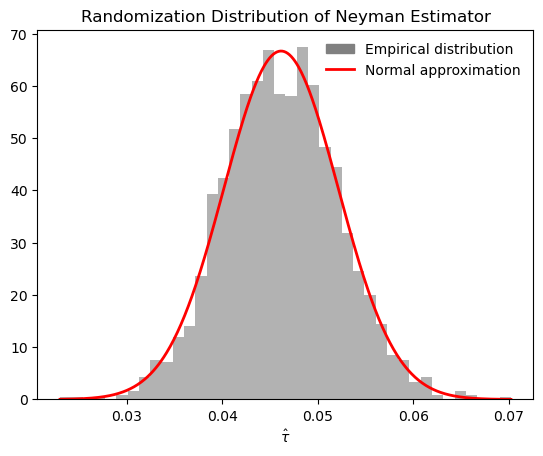

In [524]:
# Plot histogram with normal density overlay

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

plt.hist(tau_hats, color = 'gray', bins=40, density=True,
         alpha=0.6)
plt.title("Randomization Distribution of Neyman Estimator")
plt.xlabel(r'$\hat{\tau}$')

x = np.linspace(min(tau_hats), max(tau_hats), 500)
y = norm.pdf(x, loc=mean_tau, scale=np.sqrt(var_tau))
plt.plot(x, y, color='red', linewidth=2)

legend = [Patch(facecolor='gray', edgecolor='gray', label='Empirical distribution'),
                   Line2D([0], [0], color='red', lw=2, label='Normal approximation')]
plt.legend(handles=legend, loc='upper right', frameon=False)

## Section 6: Coverage of Neyman confidence intervals
#### For each randomization, compute $\hat{\tau}$ and its Neyman CI, and check whether the true finite-population ATE is covered.

In [526]:
cover = np.zeros(B, dtype=bool)

for b in range(B):
    Zb = np.zeros(N, dtype=int)
    Zb[np.random.choice(N, n1, replace=False)] = 1
    Y_obs_b = (Zb * Y1) + ((1 - Zb) * Y0)
  
    Y_T_b = Y_obs_b[Zb == 1].mean()
    Y_C_b = Y_obs_b[Zb == 0].mean()
    tau_hat_b = Y_T_b - Y_C_b

    s1_sq_b = Y_obs_b[Zb == 1].var(ddof=1)
    s0_sq_b = Y_obs_b[Zb == 0].var(ddof=1)
    var_hat_b = (s1_sq_b / n1) + (s0_sq_b / n0)
    se_hat_b = np.sqrt(var_hat_b)

    ci_lower_b = tau_hat_b - (z_crit * se_hat_b)
    ci_upper_b = tau_hat_b + (z_crit * se_hat_b)

    cover[b] = (tau_fp >= ci_lower_b) and (tau_fp <= ci_upper_b)

cover.mean()

0.9935

#### This is the empirical coverage probability of the Neyman CI.
#### It should be close to (or slightly above) the nominal level (e.g., 0.95), reflecting the conservativeness of the variance estimator.